In [1]:
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm
import torch
from torch import nn, optim
from torch.utils.data import DataLoader, Dataset
import yfinance as yf

# Xử lý dữ liệu

## Lấy dữ liệu

Lấy dữ liệu từ file CSV

In [2]:
# Lấy dữ liệu từ nguồn sẵn có
import sys
import os
import talib as ta
sys.path.append('d:\\NCKH\\SARSA_FinancialRL')  # Thêm đường dẫn gốc để import module

import pandas as pd
from data.data_processor.feature_engineer import engineer_stat as es
from data.split_data.split import split_data_two_parts
from environments.stock_trading_env.mdp import StockTradingMDP as stockMDP
from agents.d_sarsa.d_sarsa import train_deep_sarsa

# Định nghĩa đường dẫn gốc
base_path = 'd:\\NCKH\\SARSA_FinancialRL'

# Lấy dữ liệu tạm từ nguồn sẵn có
csv_path = os.path.join(base_path, 'data', 'data_storer', 'data_research', 'SSI_data.csv')
df = pd.read_csv(csv_path)
df

,time,open,high,low,close,volume
0,20/06/2012,4.38,4.43,4.34,4.38,1036710
1,21/06/2012,4.34,4.41,4.34,4.34,617320
2,22/06/2012,4.32,4.36,4.26,4.34,1620950
3,25/06/2012,4.34,4.34,4.22,4.26,1565690
4,26/06/2012,4.22,4.22,4.12,4.12,1862410
...,...,...,...,...,...,...
3128,25/12/2024,25.36,26.09,25.26,25.89,26237763
3129,26/12/2024,25.84,25.94,25.70,25.70,8770905
3130,27/12/2024,25.75,26.04,25.65,25.94,16356516
3131,30/12/2024,25.94,26.23,25.79,25.79,11501673


## Tính toán các chỉ báo kĩ thuật

In [3]:
df['time'] = pd.to_datetime(df['time'])
df = df.sort_values('time').reset_index(drop=True)

# Đường dẫn đến file FX
fx_csv_path = os.path.join(base_path, 'data', 'data_storer', 'data_research', 'USDVND_2013_2024.csv')

# Gọi hàm với start_date và config tùy chỉnh, thêm FX correlation
start_date = pd.to_datetime('01-01-2013', format='%d-%m-%Y')
price_history = es.add_technical_indicators(
    df, 
    start_date=start_date,
    vwap_period=14,  # Thêm tham số VWAP với chu kỳ 14 ngày
    fx_csv_path=fx_csv_path,  # Thêm đường dẫn FX data
    corr_window=30  # Rolling correlation window 30 ngày
)

# Chuyển đổi VWAP thành tỷ lệ tương đối
price_history['VWAP'] = (price_history['close'] - price_history['VWAP']) / price_history['VWAP']

# Hiển thị thông tin về chỉ báo mới
print(f"\n{'='*80}")
print(f"THÔNG TIN DỮ LIỆU SAU KHI THÊM CHỈ BÁO")
print(f"{'='*80}")
print(f"Số cột: {len(price_history.columns)}")
print(f"Các cột: {price_history.columns.tolist()}")
print(f"Số dòng: {len(price_history)}")

# Kiểm tra giá trị NaN trong toàn bộ DataFrame
print(f"\n{'='*80}")
print(f"KIỂM TRA GIÁ TRỊ NaN")
print(f"{'='*80}")
nan_counts = price_history.isnull().sum()
print("Số lượng NaN trong mỗi cột:")
for col, count in nan_counts.items():
    if count > 0:
        print(f"  {col}: {count} NaN values ({count/len(price_history)*100:.2f}%)")
    else:
        print(f"  {col}: Không có NaN ✓")

# Kiểm tra chi tiết CORR_FX
print(f"\n{'='*80}")
print(f"THỐNG KÊ CHỈ BÁO CORR_FX")
print(f"{'='*80}")
print(f"Min: {price_history['CORR_FX'].min():.6f}")
print(f"Max: {price_history['CORR_FX'].max():.6f}")
print(f"Mean: {price_history['CORR_FX'].mean():.6f}")
print(f"Std: {price_history['CORR_FX'].std():.6f}")
print(f"Số giá trị = 0: {(price_history['CORR_FX'] == 0).sum()} ({(price_history['CORR_FX'] == 0).sum()/len(price_history)*100:.2f}%)")

# Kiểm tra merge ngày tháng - So sánh 10 dòng đầu
print(f"\n{'='*80}")
print(f"KIỂM TRA MERGE NGÀY THÁNG (10 dòng đầu)")
print(f"{'='*80}")
print(price_history[['time', 'close', 'CORR_FX']].head(10).to_string(index=False))

# Kiểm tra một số ngày cụ thể xem có lệch không
print(f"\n{'='*80}")
print(f"KIỂM TRA NGÀY CỤ THỂ")
print(f"{'='*80}")
sample_indices = [i for i in range(0, len(price_history), len(price_history)//5)][:5]  # Lấy 5 mốc chỉ số đều nhau
for idx in sample_indices:
    row = price_history.iloc[idx]
    date = pd.to_datetime(row['time'])
    print(f"Ngày {date.strftime('%d/%m/%Y')}: Close={row['close']:.2f}, CORR_FX={row['CORR_FX']:.6f}")

# df_with_indicators giờ đã có các cột chỉ số (MACD, RSI, CCI, ADX, VWAP, CORR_FX)
price_history


THÔNG TIN DỮ LIỆU SAU KHI THÊM CHỈ BÁO
Số cột: 12
Các cột: ['time', 'open', 'high', 'low', 'close', 'volume', 'MACD', 'RSI', 'CCI', 'ADX', 'VWAP', 'CORR_FX']
Số dòng: 2996

KIỂM TRA GIÁ TRỊ NaN
Số lượng NaN trong mỗi cột:
  time: Không có NaN ✓
  open: Không có NaN ✓
  high: Không có NaN ✓
  low: Không có NaN ✓
  close: Không có NaN ✓
  volume: Không có NaN ✓
  MACD: Không có NaN ✓
  RSI: Không có NaN ✓
  CCI: Không có NaN ✓
  ADX: Không có NaN ✓
  VWAP: Không có NaN ✓
  CORR_FX: Không có NaN ✓

THỐNG KÊ CHỈ BÁO CORR_FX
Min: -0.545846
Max: 0.500246
Mean: 0.005722
Std: 0.184036
Số giá trị = 0: 0 (0.00%)

KIỂM TRA MERGE NGÀY THÁNG (10 dòng đầu)
      time  close   CORR_FX
02/01/2013   3.57 -0.057083
03/01/2013   3.48 -0.105067
04/01/2013   3.52 -0.129369
07/01/2013   3.52 -0.126407
08/01/2013   3.67 -0.061838
09/01/2013   3.67 -0.041816
10/01/2013   3.80 -0.067278
11/01/2013   3.84 -0.126964
14/01/2013   3.80 -0.195063
15/01/2013   3.90 -0.223603

KIỂM TRA NGÀY CỤ THỂ
Ngày 01/02/2013: C

C:\Users\Admin\AppData\Local\Temp\ipykernel_23280\1050581944.py:1: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['time'] = pd.to_datetime(df['time'])
d:\NCKH\SARSA_FinancialRL\data\data_processor\feature_engineer\engineer_stat.py:73: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  rolling_corr = rolling_corr.fillna(method='bfill').fillna(method='ffill').fillna(0)
C:\Users\Admin\AppData\Local\Temp\ipykernel_23280\1050581944.py:63: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  date = pd.to_datetime(row['time'])


,time,open,high,low,close,volume,MACD,RSI,CCI,ADX,VWAP,CORR_FX
0,02/01/2013,3.50,3.61,3.50,3.57,2474280,0.094378,75.431950,185.549380,28.636122,0.076833,-0.057083
1,03/01/2013,3.54,3.57,3.44,3.48,2733270,0.097665,65.902947,130.642302,29.536939,0.039693,-0.105067
2,04/01/2013,3.46,3.57,3.44,3.52,2132210,0.102319,67.847033,121.449730,30.373412,0.044336,-0.129369
3,07/01/2013,3.57,3.61,3.52,3.52,2252310,0.104799,67.847033,124.040655,31.433910,0.036682,-0.126407
4,08/01/2013,3.50,3.69,3.50,3.67,4216410,0.117514,74.235785,140.414404,32.916084,0.067276,-0.061838
...,...,...,...,...,...,...,...,...,...,...,...,...
2991,25/12/2024,25.36,26.09,25.26,25.89,26237763,0.232005,61.402541,79.015958,23.756893,0.016709,-0.228625
2992,26/12/2024,25.84,25.94,25.70,25.70,8770905,0.242057,58.125909,80.706700,23.413817,0.009274,-0.273971
2993,27/12/2024,25.75,26.04,25.65,25.94,16356516,0.266318,60.959877,92.779136,23.291027,0.017639,-0.101861
2994,30/12/2024,25.94,26.23,25.79,25.79,11501673,0.270326,58.303973,103.212542,23.539007,0.010892,-0.105216


## Chia dữ liệu

In [4]:
# Chia dữ liệu theo khoảng thời gian cụ thể
price_history['time'] = pd.to_datetime(price_history['time'], format='%d/%m/%Y')

# Good period
good_train_SSI = price_history[(price_history['time'] >= '2013-01-01') & (price_history['time'] <= '2018-12-31')]
good_test_SSI = price_history[(price_history['time'] >= '2019-01-01') & (price_history['time'] <= '2021-12-31')]

# Bad period
bad_train_SSI = price_history[(price_history['time'] >= '2013-01-01') & (price_history['time'] <= '2021-12-31')]
bad_test_SSI = price_history[(price_history['time'] >= '2022-01-01') & (price_history['time'] <= '2023-12-31')]

print(f"Good Train SSI: {len(good_train_SSI)} rows")
good_train_SSI
print(f"Good Test SSI: {len(good_test_SSI)} rows")
good_test_SSI
print(f"Bad Train SSI: {len(bad_train_SSI)} rows")
bad_train_SSI
print(f"Bad Test SSI: {len(bad_test_SSI)} rows")
bad_test_SSI




Good Train SSI: 1496 rows
Good Test SSI: 752 rows
Bad Train SSI: 2248 rows
Bad Test SSI: 498 rows


,time,open,high,low,close,volume,MACD,RSI,CCI,ADX,VWAP,CORR_FX
2248,2022-01-04,34.74,35.34,34.34,35.07,16445000,0.274158,57.666745,61.093920,20.681681,0.033012,-0.032097
2249,2022-01-05,35.07,35.67,34.74,34.94,15701400,0.334275,56.885965,71.490937,20.447342,0.027698,-0.037738
2250,2022-01-06,34.67,35.07,34.34,34.34,13248000,0.329703,53.299091,29.482880,19.793296,0.008388,-0.039090
2251,2022-01-07,34.21,34.74,33.88,34.15,13974400,0.307207,52.177129,7.047443,18.704606,0.003395,-0.040993
2252,2022-01-10,34.15,34.41,32.79,32.79,17471200,0.177591,44.892576,-59.003453,18.042971,-0.031417,0.003080
...,...,...,...,...,...,...,...,...,...,...,...,...
2741,2023-12-25,24.63,24.93,24.44,24.78,13956840,0.151698,54.623609,16.502221,12.858575,0.001535,-0.207372
2742,2023-12-26,24.82,25.05,24.74,24.93,14008666,0.169359,56.239945,42.198920,12.099158,0.009627,-0.241891
2743,2023-12-27,25.09,25.24,24.97,24.97,16105571,0.184458,56.683056,64.806511,11.759045,0.012888,-0.219024
2744,2023-12-28,25.01,25.24,24.86,25.12,10899256,0.206151,58.384832,60.615655,11.201239,0.018750,-0.195368


In [ ]:
# Lưu các biến DataFrame thành file CSV
import os

# Thư mục train
train_dir = r'D:\nckh\SARSA_FinancialRL\data\data_storer\data_research\train'
os.makedirs(train_dir, exist_ok=True)
good_train_SSI.to_csv(os.path.join(train_dir, 'good_train_SSI.csv'), index=False)
bad_train_SSI.to_csv(os.path.join(train_dir, 'bad_train_SSI.csv'), index=False)

# Thư mục test
test_dir = r'D:\nckh\SARSA_FinancialRL\data\data_storer\data_research\test'
os.makedirs(test_dir, exist_ok=True)
good_test_SSI.to_csv(os.path.join(test_dir, 'good_test_SSI.csv'), index=False)
bad_test_SSI.to_csv(os.path.join(test_dir, 'bad_test_SSI.csv'), index=False)

print("Đã lưu tất cả file CSV thành công!")


Đã lưu tất cả file CSV thành công!


# Triển khai chính sách ngẫu nhiên
làm tiên chuẩn (baseline) để so sánh với kết quả với kết quả của ba agent sắp tới.

Chính sách này không học hỏi gì, chỉ chọn hành động ngẫu nhiên đều đặn, như tung xúc xắc để quyết định mua/bán.

Chạy trên tập test

In [5]:
train = good_train_SSI
test = good_test_SSI
# Định nghĩa danh sách hành động (A) - cần thiết cho pi_random
balance_init = 1000  # số dư ban đầu
k = 5  # số cổ phiếu tối đa
min_balance = -100  # ngưỡng số dư tối thiểu
A = [a for a in range(-k, k + 1, 1)]  # hành động: -5 đến +5

# Tạo instance của StockTradingMDP
mdp = stockMDP(balance_init=balance_init, k=k, min_balance=min_balance)

# policy
def pi_random(s, greedy=False, eps=0.2):
    return np.random.choice(A) # random policy (uniform distributed)

profits = list()
for rep in tqdm(range(20)):
    profit = mdp.interact_test(
        pi=pi_random,  # chính sách (hàm pi_random)
        train_series=train,  # DataFrame train (từ cell chia dữ liệu)
        test_series=test,  # DataFrame test (từ cell chia dữ liệu)
        series_name='test',  # chạy trên tập test
        verbose=False  # không hiển thị biểu đồ (chỉ thu thập dữ liệu)
    )
    profits.append(profit)
print("Avg Profit", np.mean(profits))
print('STD Profit', np.std(profits))

  0%|          | 0/20 [00:00<?, ?it/s]

100%|██████████| 20/20 [00:02<00:00,  9.68it/s]

Avg Profit 1369.8224369999998
STD Profit 906.6391331088184


In [6]:
good_train_SSI

,time,open,high,low,close,volume,MACD,RSI,CCI,ADX,VWAP,CORR_FX
0,2013-01-02,3.50,3.61,3.50,3.57,2474280,0.094378,75.431950,185.549380,28.636122,0.076833,-0.057083
1,2013-01-03,3.54,3.57,3.44,3.48,2733270,0.097665,65.902947,130.642302,29.536939,0.039693,-0.105067
2,2013-01-04,3.46,3.57,3.44,3.52,2132210,0.102319,67.847033,121.449730,30.373412,0.044336,-0.129369
3,2013-01-07,3.57,3.61,3.52,3.52,2252310,0.104799,67.847033,124.040655,31.433910,0.036682,-0.126407
4,2013-01-08,3.50,3.69,3.50,3.67,4216410,0.117514,74.235785,140.414404,32.916084,0.067276,-0.061838
...,...,...,...,...,...,...,...,...,...,...,...,...
1491,2018-12-24,9.59,9.66,9.28,9.32,2087580,-0.089881,32.007261,-150.581395,20.815972,-0.065642,-0.304359
1492,2018-12-25,9.13,9.28,8.90,9.27,2802250,-0.124329,31.010097,-198.301265,22.924450,-0.059157,-0.273348
1493,2018-12-26,9.25,9.35,9.18,9.20,1110080,-0.155485,29.618866,-153.937593,24.487787,-0.059785,-0.283429
1494,2018-12-27,9.39,9.47,9.32,9.32,1206330,-0.168550,35.002330,-109.069700,25.282412,-0.040228,-0.280148


In [7]:
good_test_SSI

,time,open,high,low,close,volume,MACD,RSI,CCI,ADX,VWAP,CORR_FX
1496,2019-01-02,9.21,9.28,9.06,9.14,1216350,-0.203115,31.065431,-119.207173,27.633026,-0.049731,-0.100226
1497,2019-01-03,9.14,9.14,8.89,8.97,1672220,-0.227428,27.734073,-132.837873,29.168947,-0.060283,-0.116672
1498,2019-01-04,8.97,9.04,8.78,8.97,1232910,-0.243884,27.734073,-126.605296,30.806846,-0.049858,-0.132192
1499,2019-01-07,9.25,9.25,8.99,8.99,735500,-0.252403,28.776197,-90.909091,31.165543,-0.042173,-0.129940
1500,2019-01-08,9.02,9.02,8.85,8.87,1306960,-0.265773,26.323388,-106.074443,31.825549,-0.047408,-0.134249
...,...,...,...,...,...,...,...,...,...,...,...,...
2243,2021-12-27,33.05,33.05,32.42,32.52,6529300,0.218689,44.694798,-140.751756,24.378613,-0.051990,-0.074083
2244,2021-12-28,32.62,32.79,32.29,32.29,9860100,0.087493,43.567488,-142.822434,23.966717,-0.056035,-0.067765
2245,2021-12-29,32.36,33.35,31.83,32.85,9809600,0.028380,47.068135,-112.007771,22.984362,-0.035967,-0.062258
2246,2021-12-30,33.22,34.94,33.15,34.81,16605600,0.138095,57.099014,17.469253,22.014117,0.023157,-0.076977


# Huấn luyện agent Deep - SARSA với tình huống tốt


In [8]:
"""
shared_config = {
    'episodes': 30,         # Original episodes
    'gamma': 0.6,          # Original gamma
    'alpha': 0.7,           # Original alpha
    'epsilon_start': 0.8,   # Original epsilon_start
    'epsilon_min': 0.2,     # Original epsilon_min
    'epsilon_decay': 0.9,  # Chỉnh nhẹ từ 0.98 xuống 0.95 để khám phá chậm hơn trên FPT
    'nn_epochs': 10,        # Original nn_epochs
    'nn_lr': 1e-5,          # Original nn_lr
    'enabled_agents': [1, 1,1]  # [SARSA, DQN, PG]: 1 để bật, 0 để tắt
}
"""
shared_config = {
    'episodes': 35,         # Original episodes
    'gamma': 0.95,          # Original gamma
    'alpha': 0.6,           # Original alpha
    'epsilon_start': 0.9,   # Original epsilon_start
    'epsilon_min': 0.1,     # Original epsilon_min
    'epsilon_decay': 0.95,  # Chỉnh nhẹ từ 0.98 xuống 0.95 để khám phá chậm hơn trên FPT
    'nn_epochs': 10,        # Original nn_epochs
    'nn_lr': 1e-5,          # Original nn_lr
    'enabled_agents': [1, 1,1]  # [SARSA, DQN, PG]: 1 để bật, 0 để tắt
}

"""'episodes': 35, 'gamma': 0.8369349814523732, 'alpha': 0.5680671593345815, 'epsilon_start': 0.9540941536350933, 'epsilon_min': 0.19785221090168595, 'epsilon_decay': 0.9489652036913004, 'nn_epochs': 32, 'nn_lr': 0.0002990739041169814}"""

"'episodes': 35, 'gamma': 0.8369349814523732, 'alpha': 0.5680671593345815, 'epsilon_start': 0.9540941536350933, 'epsilon_min': 0.19785221090168595, 'epsilon_decay': 0.9489652036913004, 'nn_epochs': 32, 'nn_lr': 0.0002990739041169814}"


RUNNING DEEP SARSA EXPERIMENTS


Running Deep SARSA 20 times:   0%|          | 0/20 [00:00<?, ?it/s]

Running Deep SARSA 20 times: 100%|██████████| 20/20 [16:21<00:00, 49.05s/it]



RUNNING DQN EXPERIMENTS


Running DQN 20 times: 100%|██████████| 20/20 [07:19<00:00, 21.97s/it]



RUNNING POLICY GRADIENT EXPERIMENTS


Running Policy Gradient 20 times: 100%|██████████| 20/20 [14:25<00:00, 43.26s/it]



EXPERIMENT SUMMARY

Deep SARSA:
  • Average Final Profit: $1917.76 ± $1169.21
  • ROI: 191.78%
  • Annual Return Rate: 14.32%
  • Best Training Profit: $2019.80
  • Training Stability (std): $1284.24

DQN:
  • Average Final Profit: $1515.36 ± $1375.71
  • ROI: 151.54%
  • Annual Return Rate: 12.22%
  • Best Training Profit: $1653.02
  • Training Stability (std): $1412.63

Policy Gradient:
  • Average Final Profit: $1615.21 ± $1317.53
  • ROI: 161.52%
  • Annual Return Rate: 12.77%


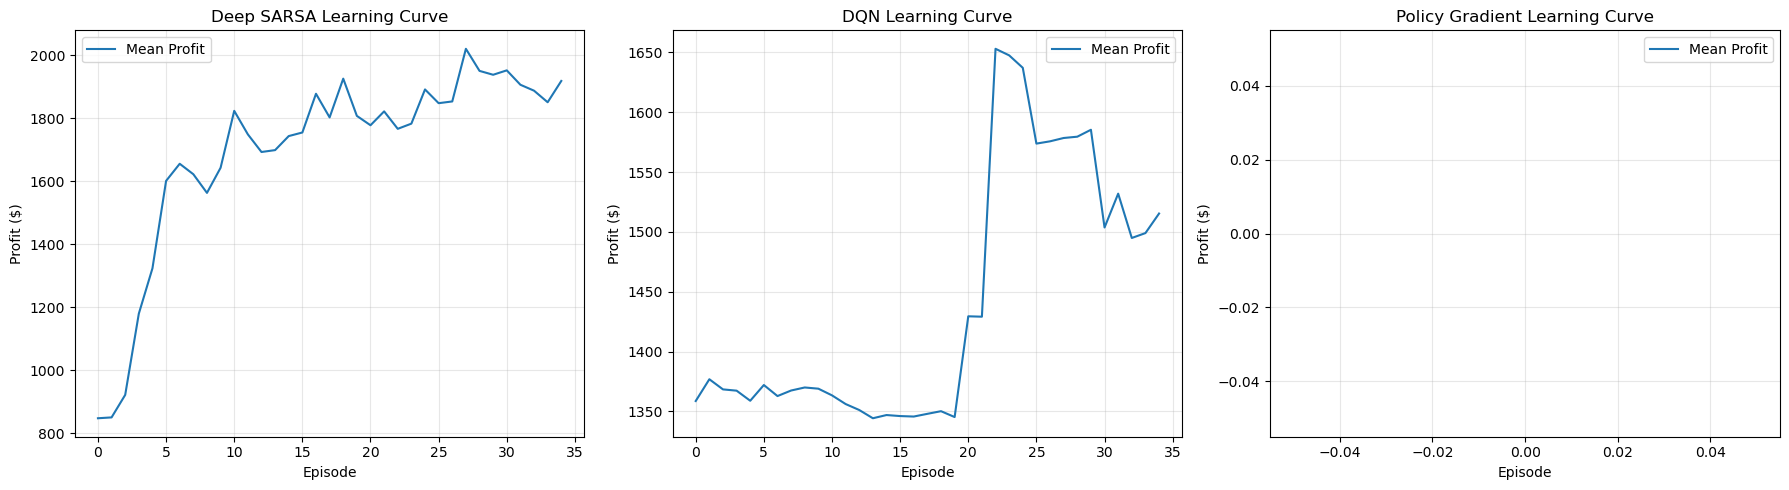


FINAL RESULTS SUMMARY

Deep SARSA:
  • Average Final Profit: $1917.76 ± $1169.21
  • Best Profit: $3368.43
  • Worst Profit: $-8.22
  • Peak Training Profit: $2019.80
  • ROI: 191.78%
  • Annual Return Rate: 42.98%
  • Total Return Rate: 191.78%
  • Volatility (Độ biến động): 28.05%
  • Sharpe Ratio (Tỷ lệ Sharpe): 0.2103
  • Max Drawdown (Sụt giảm tối đa): -39.81%
  • [DEBUG] Expected Sharpe: (42.98% - 2%) / 28.05% = 1.4610
  • [DEBUG] Negative Sharpe in 3/20 runs
  • [DEBUG] Sharpe range: [-16.6942, 2.3354]

DQN:
  • Average Final Profit: $1515.36 ± $1375.71
  • Best Profit: $3986.81
  • Worst Profit: $-3.75
  • Peak Training Profit: $1653.02
  • ROI: 151.54%
  • Annual Return Rate: 36.07%
  • Total Return Rate: 151.54%
  • Volatility (Độ biến động): 22.22%
  • Sharpe Ratio (Tỷ lệ Sharpe): 0.5341
  • Max Drawdown (Sụt giảm tối đa): -31.23%
  • [DEBUG] Expected Sharpe: (36.07% - 2%) / 22.22% = 1.5330
  • [DEBUG] Negative Sharpe in 3/20 runs
  • [DEBUG] Sharpe range: [-2.9067, 1.6486]

In [9]:
# Thêm đường dẫn gốc để import module
import sys
sys.path.append('d:\\NCKH\\SARSA_FinancialRL')

# Import run_experiments từ agents.run
from agents.run import run_experiments

# Định nghĩa shared_config với original settings từ paper, chỉnh nhẹ epsilon_decay xuống 0.95 để phù hợp với SSI data


# Chuyển lại Good Period
train = good_train_SSI
test = good_test_SSI

# Chạy thử nghiệm cho agent được bật với cùng siêu tham số
results = run_experiments(mdp, train, test, shared_config, num_runs=20)
results_good = results.copy()

# Hiển thị kết quả
import matplotlib.pyplot as plt

# Vẽ learning curves cho từng agent
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

agents = ['sarsa', 'dqn', 'pg']
titles = ['Deep SARSA', 'DQN', 'Policy Gradient']

for i, (agent, title) in enumerate(zip(agents, titles)):
    if agent in results:
        res = results[agent]
        mean_curve = res['learning_curve']
        
        axes[i].plot(mean_curve, label='Mean Profit')
        axes[i].set_title(f'{title} Learning Curve')
        axes[i].set_xlabel('Episode')
        axes[i].set_ylabel('Profit ($)')
        axes[i].legend()
        axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Định nghĩa hàm tính Annual Return Rate
def agent_annual_return(initial_capital, final_portfolio, start_date, end_date):
    total_return = (final_portfolio / initial_capital) - 1
    years = (pd.to_datetime(end_date) - pd.to_datetime(start_date)).days / 365.25
    if years <= 0: return 0, 0
    annual = (1 + total_return) ** (1 / years) - 1
    return annual * 100, total_return * 100

# Xác định start_date và end_date từ test_series
start_date = test.iloc[0]['time']
end_date = test.iloc[-1]['time']

# In tóm tắt kết quả
print("\n" + "="*80)
print("FINAL RESULTS SUMMARY")
print("="*80)

for agent in agents:
    if agent in results:
        res = results[agent]
        print(f"\n{res['agent']}:")
        print(f"  • Average Final Profit: ${res['final_profit']:.2f} ± ${res['std_final_profit']:.2f}")
        print(f"  • Best Profit: ${np.max(res['all_final_profits']):.2f}")
        print(f"  • Worst Profit: ${np.min(res['all_final_profits']):.2f}")
        if len(res['learning_curve']) > 0:
            print(f"  • Peak Training Profit: ${np.max(res['learning_curve']):.2f}")
        
        print(f"  • ROI: {res['roi']:.2f}%")
        
        # Tính Annual Return Rate
        final_portfolio = 1000 + res['final_profit']
        annual_rate, total_rate = agent_annual_return(1000, final_portfolio, start_date, end_date)
        print(f"  • Annual Return Rate: {annual_rate:.2f}%")
        print(f"  • Total Return Rate: {total_rate:.2f}%")
        
        # Hiển thị các chỉ số tài chính mới với debug info
        print(f"  • Volatility (Độ biến động): {res['volatility']:.2f}%")
        print(f"  • Sharpe Ratio (Tỷ lệ Sharpe): {res['sharpe_ratio']:.4f}")
        print(f"  • Max Drawdown (Sụt giảm tối đa): {res['max_drawdown']:.2f}%")
        
        # DEBUG: Tính Sharpe Ratio manually để kiểm tra
        expected_sharpe = (annual_rate - 2.0) / res['volatility'] if res['volatility'] > 0 else 0
        print(f"  • [DEBUG] Expected Sharpe: ({annual_rate:.2f}% - 2%) / {res['volatility']:.2f}% = {expected_sharpe:.4f}")
        
        # Kiểm tra số lần Sharpe âm trong 20 runs
        if 'all_portfolio_histories' in res:
            from agents.run import calculate_sharpe_ratio
            all_sharpes = [calculate_sharpe_ratio(ph) for ph in res['all_portfolio_histories']]
            neg_count = sum(1 for s in all_sharpes if s < 0)
            print(f"  • [DEBUG] Negative Sharpe in {neg_count}/20 runs")
            print(f"  • [DEBUG] Sharpe range: [{min(all_sharpes):.4f}, {max(all_sharpes):.4f}]")

# So sánh với baseline (random policy)
print(f"\nRandom Policy Baseline:")
print(f"  • Average Profit: ${np.mean(profits):.2f} ± ${np.std(profits):.2f}")

# Tính Annual Return Rate cho baseline
baseline_final_portfolio = 1000 + np.mean(profits)
baseline_annual_rate, baseline_total_rate = agent_annual_return(1000, baseline_final_portfolio, start_date, end_date)
print(f"  • Annual Return Rate: {baseline_annual_rate:.2f}%")
print(f"  • Total Return Rate: {baseline_total_rate:.2f}%")

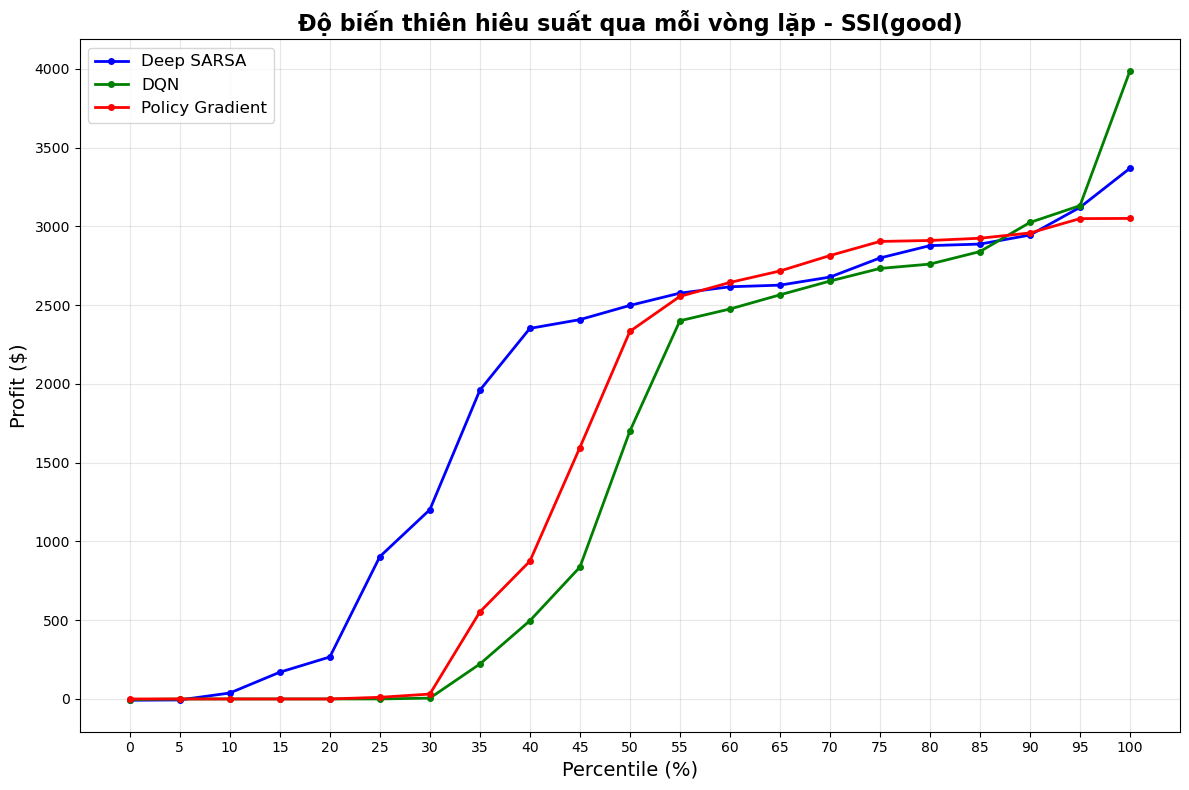

In [13]:
# Vẽ biểu đồ Percentiles Over Repeated Experiments
import matplotlib.pyplot as plt
import numpy as np

# Danh sách percentiles để vẽ (từ 0% đến 100% với bước 5%)
percentile_levels = np.arange(0, 101, 5)

# Tạo figure
plt.figure(figsize=(12, 8))

# Vẽ cho từng agent
colors = ['blue', 'green', 'red']
agents = ['sarsa', 'dqn', 'pg']
agent_names = ['Deep SARSA', 'DQN', 'Policy Gradient']

for i, (agent, name) in enumerate(zip(agents, agent_names)):
    if agent in results:
        profits = results[agent]['all_final_profits']
        sorted_profits = np.sort(profits)
        percentile_values = np.percentile(sorted_profits, percentile_levels)
        plt.plot(percentile_levels, percentile_values, 
                color=colors[i], marker='o', linestyle='-', 
                label=name, linewidth=2, markersize=4)

# Thiết lập biểu đồ
plt.title('Độ biến thiên hiêu suất qua mỗi vòng lặp - SSI(good)', fontsize=16, fontweight='bold')
plt.xlabel('Percentile (%)', fontsize=14)
plt.ylabel('Profit ($)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.xticks(percentile_levels)
plt.tight_layout()

# Hiển thị biểu đồ
plt.show()

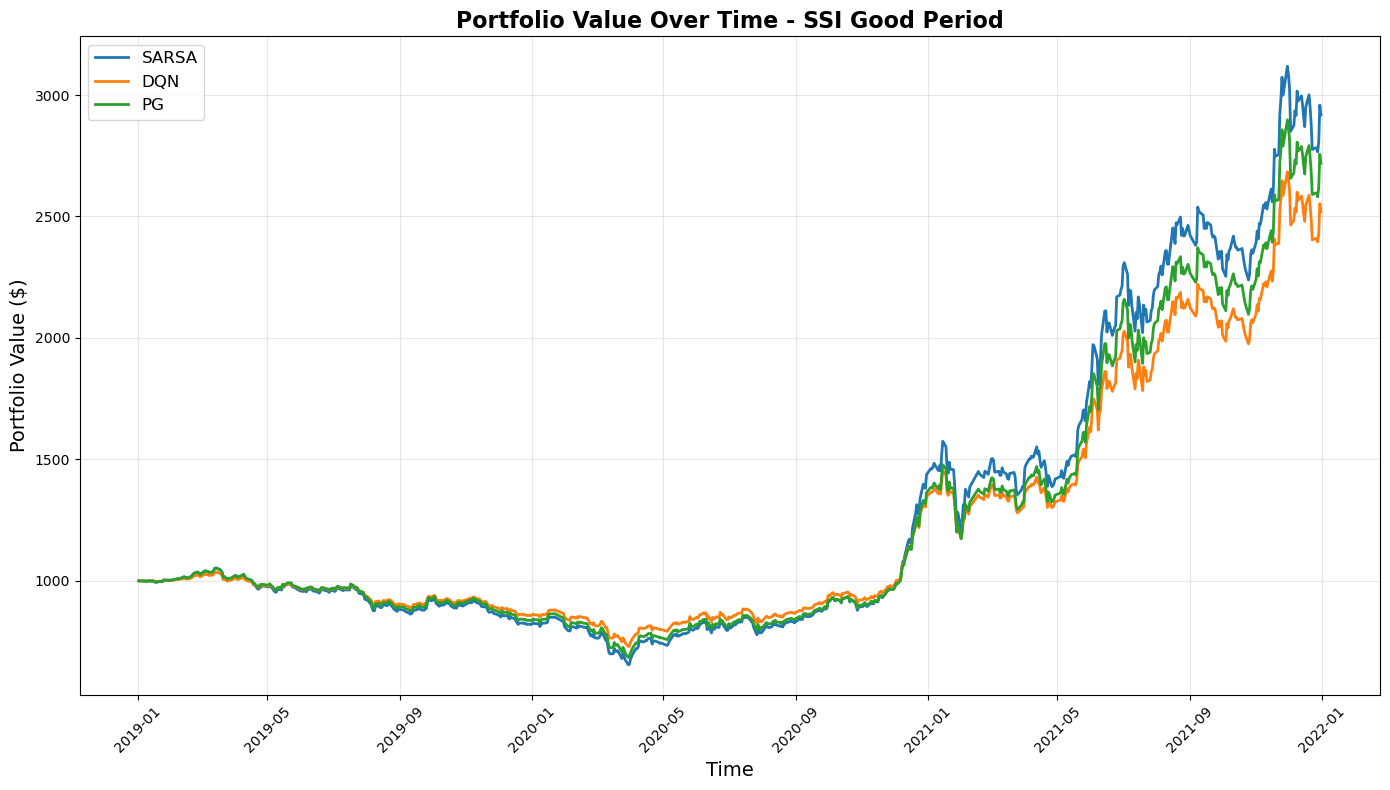

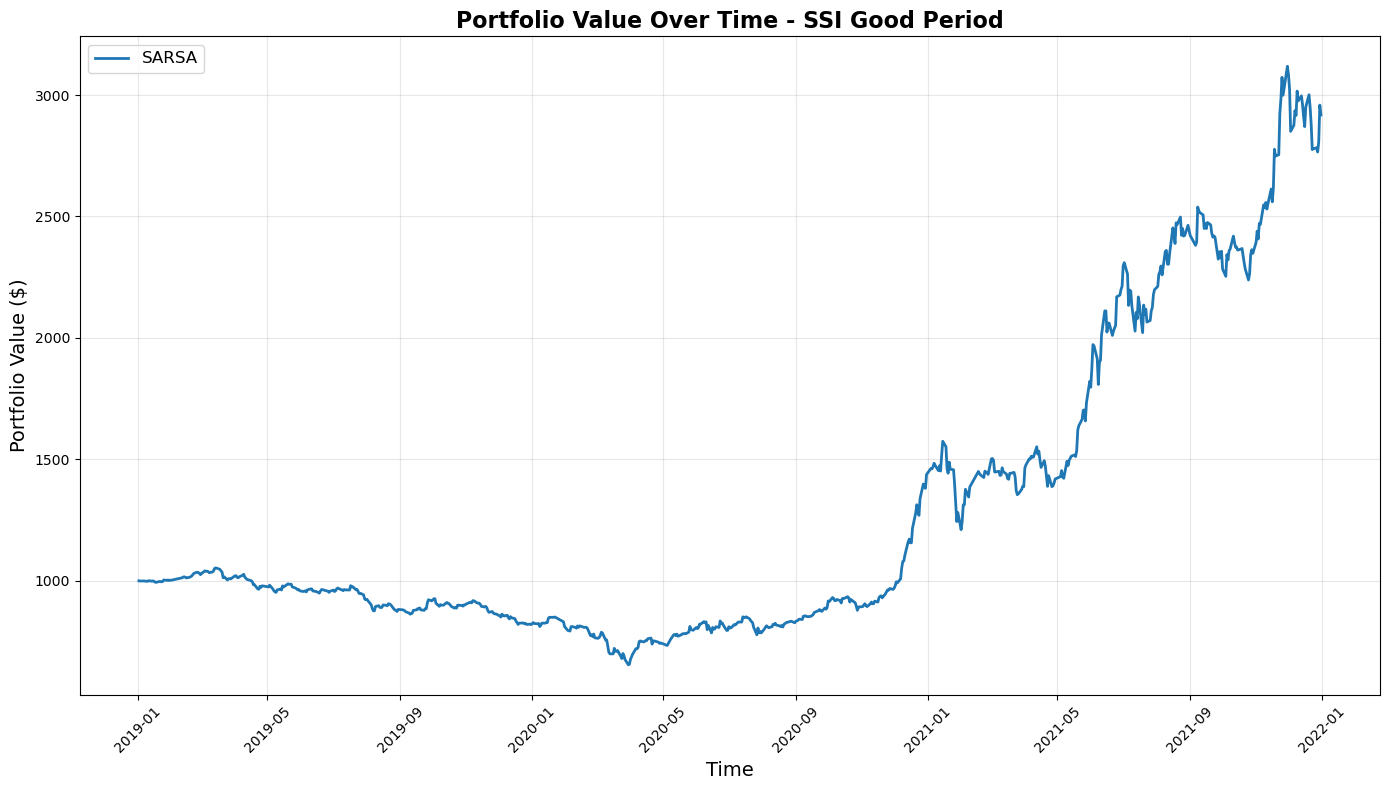

In [12]:
# Vẽ đồ thị
portfolio_histories = {}
for agent_name in ['sarsa', 'dqn', 'pg']:
    if agent_name in results:
        portfolio_histories[agent_name] = results[agent_name]['portfolio_history']

plt.figure(figsize=(14, 8))
for agent, port in portfolio_histories.items():
    # Cắt portfolio_history để khớp với len(test['time'])
    plt.plot(test['time'], port[1:], label=agent.upper(), linewidth=2)

plt.title('Portfolio Value Over Time - SSI Good Period', fontsize=16, fontweight='bold')
plt.xlabel('Time', fontsize=14)
plt.ylabel('Portfolio Value ($)', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
# Vẽ đồ thị
portfolio_histories = {}
for agent_name in ['sarsa']:
    if agent_name in results:
        portfolio_histories[agent_name] = results[agent_name]['portfolio_history']

plt.figure(figsize=(14, 8))
for agent, port in portfolio_histories.items():
    # Cắt portfolio_history để khớp với len(test['time'])
    plt.plot(test['time'], port[1:], label=agent.upper(), linewidth=2)

plt.title('Portfolio Value Over Time - SSI Good Period', fontsize=16, fontweight='bold')
plt.xlabel('Time', fontsize=14)
plt.ylabel('Portfolio Value ($)', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
import os

models_dir = r'D:\nckh\SARSA_FinancialRL\models'

os.makedirs(models_dir, exist_ok=True)

# Save trained models for SSI good period
if 'sarsa' in results:
    torch.save(results['sarsa']['trained_agent'].state_dict(), os.path.join(models_dir, 'sarsa_good.pth'))
    print("Deep SARSA model saved.")

if 'dqn' in results:
    results['dqn']['trained_agent'].save(os.path.join(models_dir, 'dqn_good.pth'))
    print("DQN model saved.")

if 'pg' in results:
    results['pg']['trained_agent'].save_model(os.path.join(models_dir, 'pg_good.pth'))
    print("Policy Gradient model saved.")

print("All models for SSI good period saved successfully!")

Deep SARSA model saved.
DQN model saved.
Policy Gradient model saved.
All models for FPT good period saved successfully!


In [ ]:
from reportlab.lib.pagesizes import letter
from reportlab.pdfgen import canvas
from reportlab.lib import colors
from reportlab.platypus import SimpleDocTemplate, Table, TableStyle, Paragraph, Spacer, Image
from reportlab.lib.styles import getSampleStyleSheet
import os

# Đảm bảo thư mục tồn tại
results_dir = r'D:\nckh\SARSA_FinancialRL\application\results'
os.makedirs(results_dir, exist_ok=True)

# Tạo PDF
pdf_path = os.path.join(results_dir, 'SSI_good_new.pdf')
doc = SimpleDocTemplate(pdf_path, pagesize=letter)
elements = []
styles = getSampleStyleSheet()

# Title
elements.append(Paragraph("Training Results for SSI Good Period", styles['Title']))
elements.append(Spacer(1, 12))

# Hyperparameters
elements.append(Paragraph("Hyperparameters:", styles['Heading2']))
hp_text = f"""
Episodes: {shared_config['episodes']}
Gamma: {shared_config['gamma']}
Alpha: {shared_config['alpha']}
Epsilon Start: {shared_config['epsilon_start']}
Epsilon Min: {shared_config['epsilon_min']}
Epsilon Decay: {shared_config['epsilon_decay']}
NN Epochs: {shared_config['nn_epochs']}
NN LR: {shared_config['nn_lr']}
Enabled Agents: {shared_config['enabled_agents']}
"""
elements.append(Paragraph(hp_text, styles['Normal']))
elements.append(Spacer(1, 12))

# Results Table
elements.append(Paragraph("Training Results:", styles['Heading2']))

# Tạo data cho table với các chỉ số mới
data = [['Agent', 'Avg Profit', 'ROI', 'Annual Return', 'Volatility', 'Sharpe Ratio', 'Max Drawdown']]
for agent in agents:
    if agent in results:
        res = results[agent]
        avg_profit = f"${res['final_profit']:.2f}"
        roi = f"{res['roi']:.2f}%"
        final_portfolio = 1000 + res['final_profit']
        annual_rate, total_rate = agent_annual_return(1000, final_portfolio, start_date, end_date)
        annual = f"{annual_rate:.2f}%"
        volatility = f"{res['volatility']:.2f}%"
        sharpe = f"{res['sharpe_ratio']:.4f}"
        drawdown = f"{res['max_drawdown']:.2f}%"
        data.append([res['agent'], avg_profit, roi, annual, volatility, sharpe, drawdown])

# Baseline
baseline_avg = f"${np.mean(profits):.2f}"
baseline_final_portfolio = 1000 + np.mean(profits)
baseline_annual_rate, baseline_total_rate = agent_annual_return(1000, baseline_final_portfolio, start_date, end_date)
data.append(['Random Baseline', baseline_avg, f"{((np.mean(profits)/1000)*100):.2f}%", f"{baseline_annual_rate:.2f}%", 'N/A', 'N/A', 'N/A'])

table = Table(data)
table.setStyle(TableStyle([
    ('BACKGROUND', (0,0), (-1,0), colors.grey),
    ('TEXTCOLOR', (0,0), (-1,0), colors.whitesmoke),
    ('ALIGN', (0,0), (-1,-1), 'CENTER'),
    ('FONTNAME', (0,0), (-1,0), 'Helvetica-Bold'),
    ('FONTSIZE', (0,0), (-1,-1), 8),
    ('BOTTOMPADDING', (0,0), (-1,0), 12),
    ('BACKGROUND', (0,1), (-1,-1), colors.beige),
    ('GRID', (0,0), (-1,-1), 1, colors.black)
]))
elements.append(table)
elements.append(Spacer(1, 12))

# Detailed Statistics Table
elements.append(Paragraph("Detailed Statistics:", styles['Heading2']))
detailed_data = [['Agent', 'Best Profit', 'Worst Profit', 'Peak Training', 'Total Return']]
for agent in agents:
    if agent in results:
        res = results[agent]
        best = f"${np.max(res['all_final_profits']):.2f}"
        worst = f"${np.min(res['all_final_profits']):.2f}"
        peak = f"${np.max(res['learning_curve']):.2f}" if len(res['learning_curve']) > 0 else 'N/A'
        final_portfolio = 1000 + res['final_profit']
        annual_rate, total_rate = agent_annual_return(1000, final_portfolio, start_date, end_date)
        total = f"{total_rate:.2f}%"
        detailed_data.append([res['agent'], best, worst, peak, total])

detailed_table = Table(detailed_data)
detailed_table.setStyle(TableStyle([
    ('BACKGROUND', (0,0), (-1,0), colors.grey),
    ('TEXTCOLOR', (0,0), (-1,0), colors.whitesmoke),
    ('ALIGN', (0,0), (-1,-1), 'CENTER'),
    ('FONTNAME', (0,0), (-1,0), 'Helvetica-Bold'),
    ('BOTTOMPADDING', (0,0), (-1,0), 12),
    ('BACKGROUND', (0,1), (-1,-1), colors.beige),
    ('GRID', (0,0), (-1,-1), 1, colors.black)
]))
elements.append(detailed_table)
elements.append(Spacer(1, 12))

# Biểu đồ Learning Curves
elements.append(Paragraph("Learning Curves:", styles['Heading2']))
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, (agent, title) in enumerate(zip(agents, titles)):
    if agent in results:
        res = results[agent]
        mean_curve = res['learning_curve']
        axes[i].plot(mean_curve, label='Mean Profit')
        axes[i].set_title(f'{title} Learning Curve')
        axes[i].set_xlabel('Episode')
        axes[i].set_ylabel('Profit ($)')
        axes[i].legend()
        axes[i].grid(alpha=0.3)
plt.tight_layout()
learning_curve_path = os.path.join(results_dir, 'learning_curves.png')
plt.savefig(learning_curve_path)
plt.close()
elements.append(Image(learning_curve_path, width=500, height=300))

# Biểu đồ Percentiles
elements.append(Paragraph("Profit Percentiles:", styles['Heading2']))
agent_names = titles
plt.figure(figsize=(12, 8))
color_list = ['blue', 'green', 'red']
for i, (agent, name) in enumerate(zip(agents, agent_names)):
    if agent in results:
        agent_profits = results[agent]['all_final_profits']
        sorted_profits = np.sort(agent_profits)
        percentile_values = np.percentile(sorted_profits, percentile_levels)
        plt.plot(percentile_levels, percentile_values, color=color_list[i], marker='o', linestyle='-', label=name, linewidth=2, markersize=4)
plt.title('Độ biến thiên hiệu suất qua mỗi vòng lặp - SSI', fontsize=16, fontweight='bold')
plt.xlabel('Percentile (%)', fontsize=14)
plt.ylabel('Profit ($)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.xticks(percentile_levels)
plt.tight_layout()
percentile_path = os.path.join(results_dir, 'percentiles.png')
plt.savefig(percentile_path)
plt.close()
elements.append(Image(percentile_path, width=500, height=400))

# Biểu đồ Portfolio Value Over Time
elements.append(Paragraph("Portfolio Value Over Time:", styles['Heading2']))
portfolio_histories = {}
for agent_name in ['sarsa', 'dqn', 'pg']:
    if agent_name in results:
        portfolio_histories[agent_name] = results[agent_name]['portfolio_history']

plt.figure(figsize=(14, 8))
for agent, port in portfolio_histories.items():
    plt.plot(test['time'], port[1:], label=agent.upper(), linewidth=2)
plt.title('Portfolio Value Over Time - SSI Good Period', fontsize=16, fontweight='bold')
plt.xlabel('Time', fontsize=14)
plt.ylabel('Portfolio Value ($)', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
portfolio_path = os.path.join(results_dir, 'portfolio_value_good.png')
plt.savefig(portfolio_path)
plt.close()
elements.append(Image(portfolio_path, width=500, height=400))

# Build PDF
doc.build(elements)
print(f"PDF saved to {pdf_path}")

PDF saved to D:\nckh\SARSA_FinancialRL\application\results\ACB_good_new.pdf


In [14]:
bad_train_SSI

,time,open,high,low,close,volume,MACD,RSI,CCI,ADX,VWAP,CORR_FX
0,2013-01-02,3.50,3.61,3.50,3.57,2474280,0.094378,75.431950,185.549380,28.636122,0.076833,-0.057083
1,2013-01-03,3.54,3.57,3.44,3.48,2733270,0.097665,65.902947,130.642302,29.536939,0.039693,-0.105067
2,2013-01-04,3.46,3.57,3.44,3.52,2132210,0.102319,67.847033,121.449730,30.373412,0.044336,-0.129369
3,2013-01-07,3.57,3.61,3.52,3.52,2252310,0.104799,67.847033,124.040655,31.433910,0.036682,-0.126407
4,2013-01-08,3.50,3.69,3.50,3.67,4216410,0.117514,74.235785,140.414404,32.916084,0.067276,-0.061838
...,...,...,...,...,...,...,...,...,...,...,...,...
2243,2021-12-27,33.05,33.05,32.42,32.52,6529300,0.218689,44.694798,-140.751756,24.378613,-0.051990,-0.074083
2244,2021-12-28,32.62,32.79,32.29,32.29,9860100,0.087493,43.567488,-142.822434,23.966717,-0.056035,-0.067765
2245,2021-12-29,32.36,33.35,31.83,32.85,9809600,0.028380,47.068135,-112.007771,22.984362,-0.035967,-0.062258
2246,2021-12-30,33.22,34.94,33.15,34.81,16605600,0.138095,57.099014,17.469253,22.014117,0.023157,-0.076977


In [15]:
bad_test_SSI

,time,open,high,low,close,volume,MACD,RSI,CCI,ADX,VWAP,CORR_FX
2248,2022-01-04,34.74,35.34,34.34,35.07,16445000,0.274158,57.666745,61.093920,20.681681,0.033012,-0.032097
2249,2022-01-05,35.07,35.67,34.74,34.94,15701400,0.334275,56.885965,71.490937,20.447342,0.027698,-0.037738
2250,2022-01-06,34.67,35.07,34.34,34.34,13248000,0.329703,53.299091,29.482880,19.793296,0.008388,-0.039090
2251,2022-01-07,34.21,34.74,33.88,34.15,13974400,0.307207,52.177129,7.047443,18.704606,0.003395,-0.040993
2252,2022-01-10,34.15,34.41,32.79,32.79,17471200,0.177591,44.892576,-59.003453,18.042971,-0.031417,0.003080
...,...,...,...,...,...,...,...,...,...,...,...,...
2741,2023-12-25,24.63,24.93,24.44,24.78,13956840,0.151698,54.623609,16.502221,12.858575,0.001535,-0.207372
2742,2023-12-26,24.82,25.05,24.74,24.93,14008666,0.169359,56.239945,42.198920,12.099158,0.009627,-0.241891
2743,2023-12-27,25.09,25.24,24.97,24.97,16105571,0.184458,56.683056,64.806511,11.759045,0.012888,-0.219024
2744,2023-12-28,25.01,25.24,24.86,25.12,10899256,0.206151,58.384832,60.615655,11.201239,0.018750,-0.195368


# Huấn luyện trên trường hợp xấu 


RUNNING DEEP SARSA EXPERIMENTS


Running Deep SARSA 20 times: 100%|██████████| 20/20 [20:45<00:00, 62.27s/it]



RUNNING DQN EXPERIMENTS


Running DQN 20 times: 100%|██████████| 20/20 [08:08<00:00, 24.44s/it]



RUNNING POLICY GRADIENT EXPERIMENTS


Running Policy Gradient 20 times: 100%|██████████| 20/20 [12:41<00:00, 38.06s/it]



EXPERIMENT SUMMARY

Deep SARSA:
  • Average Final Profit: $-148.72 ± $155.31
  • ROI: -14.87%
  • Annual Return Rate: -1.99%
  • Best Training Profit: $-100.96
  • Training Stability (std): $153.58

DQN:
  • Average Final Profit: $-98.26 ± $107.65
  • ROI: -9.83%
  • Annual Return Rate: -1.28%
  • Best Training Profit: $0.91
  • Training Stability (std): $118.69

Policy Gradient:
  • Average Final Profit: $-154.85 ± $142.48
  • ROI: -15.48%
  • Annual Return Rate: -2.08%


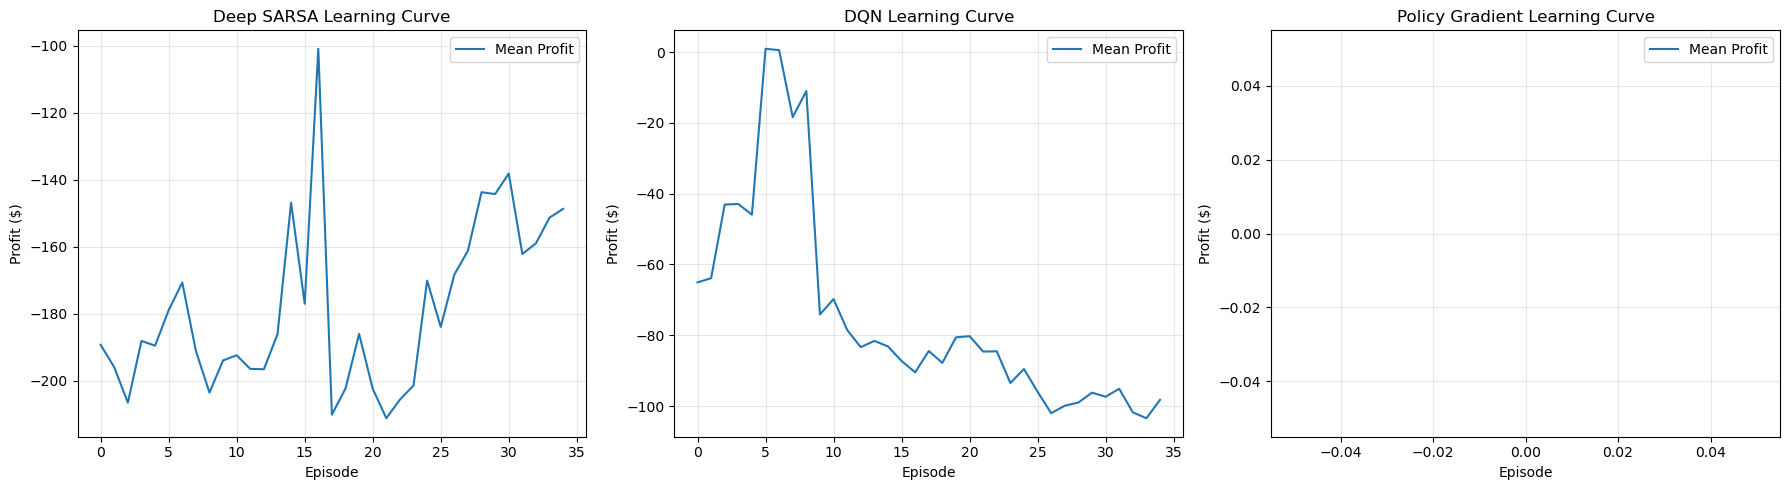


FINAL RESULTS SUMMARY

Deep SARSA:
  • Average Final Profit: $-148.72 ± $155.31
  • Best Profit: $234.87
  • Worst Profit: $-334.86
  • Peak Training Profit: $-100.96
  • ROI: -14.87%
  • Annual Return Rate: -7.80%
  • Total Return Rate: -14.87%
  • Volatility (Độ biến động): 38.82%
  • Sharpe Ratio (Tỷ lệ Sharpe): 0.0823
  • Max Drawdown (Sụt giảm tối đa): -54.16%

DQN:
  • Average Final Profit: $-98.26 ± $107.65
  • Best Profit: $29.07
  • Worst Profit: $-354.34
  • Peak Training Profit: $0.91
  • ROI: -9.83%
  • Annual Return Rate: -5.08%
  • Total Return Rate: -9.83%
  • Volatility (Độ biến động): 25.68%
  • Sharpe Ratio (Tỷ lệ Sharpe): -0.1624
  • Max Drawdown (Sụt giảm tối đa): -36.05%

Policy Gradient:
  • Average Final Profit: $-154.85 ± $142.48
  • Best Profit: $74.59
  • Worst Profit: $-370.04
  • ROI: -15.48%
  • Annual Return Rate: -8.14%
  • Total Return Rate: -15.48%
  • Volatility (Độ biến động): 30.94%
  • Sharpe Ratio (Tỷ lệ Sharpe): -0.1511
  • Max Drawdown (Sụt giảm

In [16]:
# Thêm đường dẫn gốc để import module
import sys
sys.path.append('d:\\NCKH\\SARSA_FinancialRL')

# Import run_experiments từ agents.run
from agents.run import run_experiments

# Định nghĩa shared_config với original settings từ paper, chỉnh nhẹ epsilon_decay xuống 0.95 để phù hợp với SSI data


# Chuyển lại Good Period
train = bad_train_SSI
test = bad_test_SSI

# Chạy thử nghiệm cho agent được bật với cùng siêu tham số
results = run_experiments(mdp, train, test, shared_config, num_runs=20)
results_good = results.copy()

# Hiển thị kết quả
import matplotlib.pyplot as plt

# Vẽ learning curves cho từng agent
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

agents = ['sarsa', 'dqn', 'pg']
titles = ['Deep SARSA', 'DQN', 'Policy Gradient']

for i, (agent, title) in enumerate(zip(agents, titles)):
    if agent in results:
        res = results[agent]
        mean_curve = res['learning_curve']
        
        axes[i].plot(mean_curve, label='Mean Profit')
        axes[i].set_title(f'{title} Learning Curve')
        axes[i].set_xlabel('Episode')
        axes[i].set_ylabel('Profit ($)')
        axes[i].legend()
        axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Định nghĩa hàm tính Annual Return Rate
def agent_annual_return(initial_capital, final_portfolio, start_date, end_date):
    total_return = (final_portfolio / initial_capital) - 1
    years = (pd.to_datetime(end_date) - pd.to_datetime(start_date)).days / 365.25
    if years <= 0: return 0, 0
    annual = (1 + total_return) ** (1 / years) - 1
    return annual * 100, total_return * 100

# Xác định start_date và end_date từ test_series
start_date = test.iloc[0]['time']
end_date = test.iloc[-1]['time']

# In tóm tắt kết quả
print("\n" + "="*80)
print("FINAL RESULTS SUMMARY")
print("="*80)

for agent in agents:
    if agent in results:
        res = results[agent]
        print(f"\n{res['agent']}:")
        print(f"  • Average Final Profit: ${res['final_profit']:.2f} ± ${res['std_final_profit']:.2f}")
        print(f"  • Best Profit: ${np.max(res['all_final_profits']):.2f}")
        print(f"  • Worst Profit: ${np.min(res['all_final_profits']):.2f}")
        if len(res['learning_curve']) > 0:
            print(f"  • Peak Training Profit: ${np.max(res['learning_curve']):.2f}")
        
        print(f"  • ROI: {res['roi']:.2f}%")
        
        # Tính Annual Return Rate
        final_portfolio = 1000 + res['final_profit']
        annual_rate, total_rate = agent_annual_return(1000, final_portfolio, start_date, end_date)
        print(f"  • Annual Return Rate: {annual_rate:.2f}%")
        print(f"  • Total Return Rate: {total_rate:.2f}%")
        
        # Hiển thị các chỉ số tài chính mới
        print(f"  • Volatility (Độ biến động): {res['volatility']:.2f}%")
        print(f"  • Sharpe Ratio (Tỷ lệ Sharpe): {res['sharpe_ratio']:.4f}")
        print(f"  • Max Drawdown (Sụt giảm tối đa): {res['max_drawdown']:.2f}%")

# So sánh với baseline (random policy)
print(f"\nRandom Policy Baseline:")
print(f"  • Average Profit: ${np.mean(profits):.2f} ± ${np.std(profits):.2f}")

# Tính Annual Return Rate cho baseline
baseline_final_portfolio = 1000 + np.mean(profits)
baseline_annual_rate, baseline_total_rate = agent_annual_return(1000, baseline_final_portfolio, start_date, end_date)
print(f"  • Annual Return Rate: {baseline_annual_rate:.2f}%")
print(f"  • Total Return Rate: {baseline_total_rate:.2f}%")

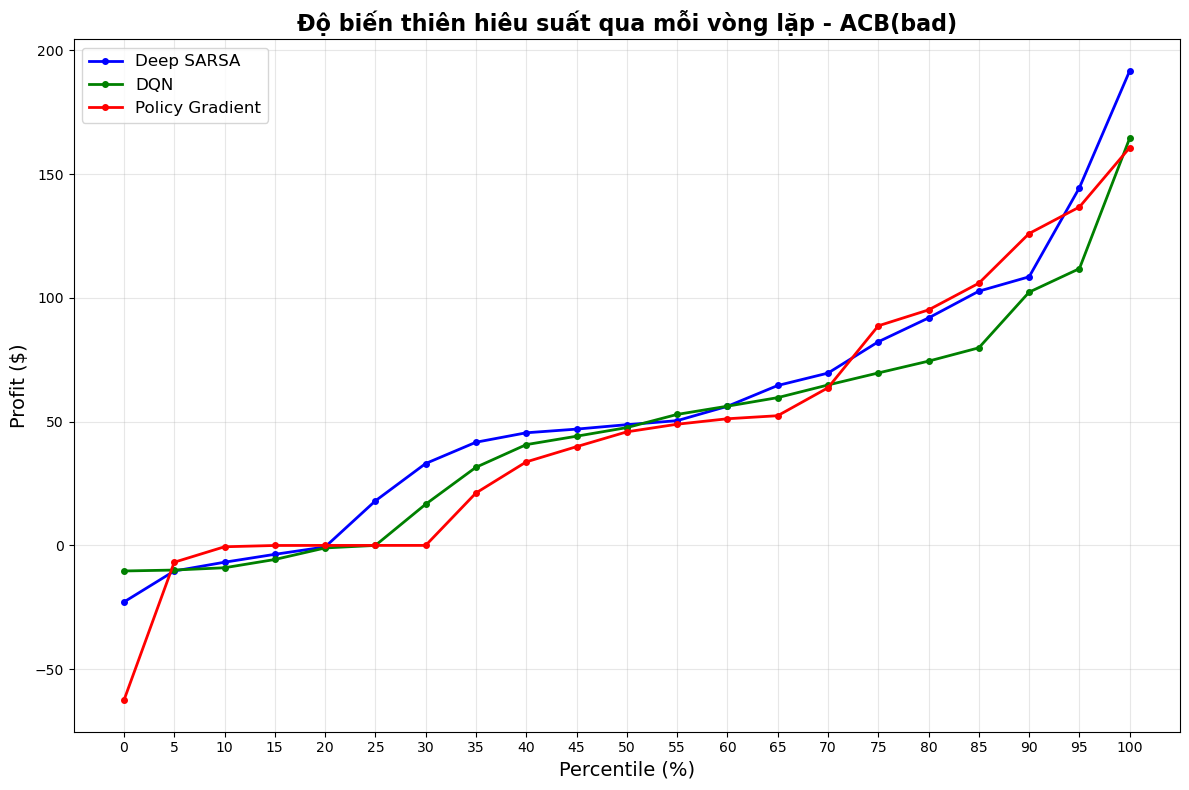

In [ ]:
# Vẽ biểu đồ Percentiles Over Repeated Experiments
import matplotlib.pyplot as plt
import numpy as np

# Danh sách percentiles để vẽ (từ 0% đến 100% với bước 5%)
percentile_levels = np.arange(0, 101, 5)

# Tạo figure
plt.figure(figsize=(12, 8))

# Vẽ cho từng agent
colors = ['blue', 'green', 'red']
agents = ['sarsa', 'dqn', 'pg']
agent_names = ['Deep SARSA', 'DQN', 'Policy Gradient']

for i, (agent, name) in enumerate(zip(agents, agent_names)):
    if agent in results:
        profits = results[agent]['all_final_profits']
        sorted_profits = np.sort(profits)
        percentile_values = np.percentile(sorted_profits, percentile_levels)
        plt.plot(percentile_levels, percentile_values, 
                color=colors[i], marker='o', linestyle='-', 
                label=name, linewidth=2, markersize=4)

# Thiết lập biểu đồ
plt.title('Độ biến thiên hiêu suất qua mỗi vòng lặp - SSI(bad)', fontsize=16, fontweight='bold')
plt.xlabel('Percentile (%)', fontsize=14)
plt.ylabel('Profit ($)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.xticks(percentile_levels)
plt.tight_layout()

# Hiển thị biểu đồ
plt.show()

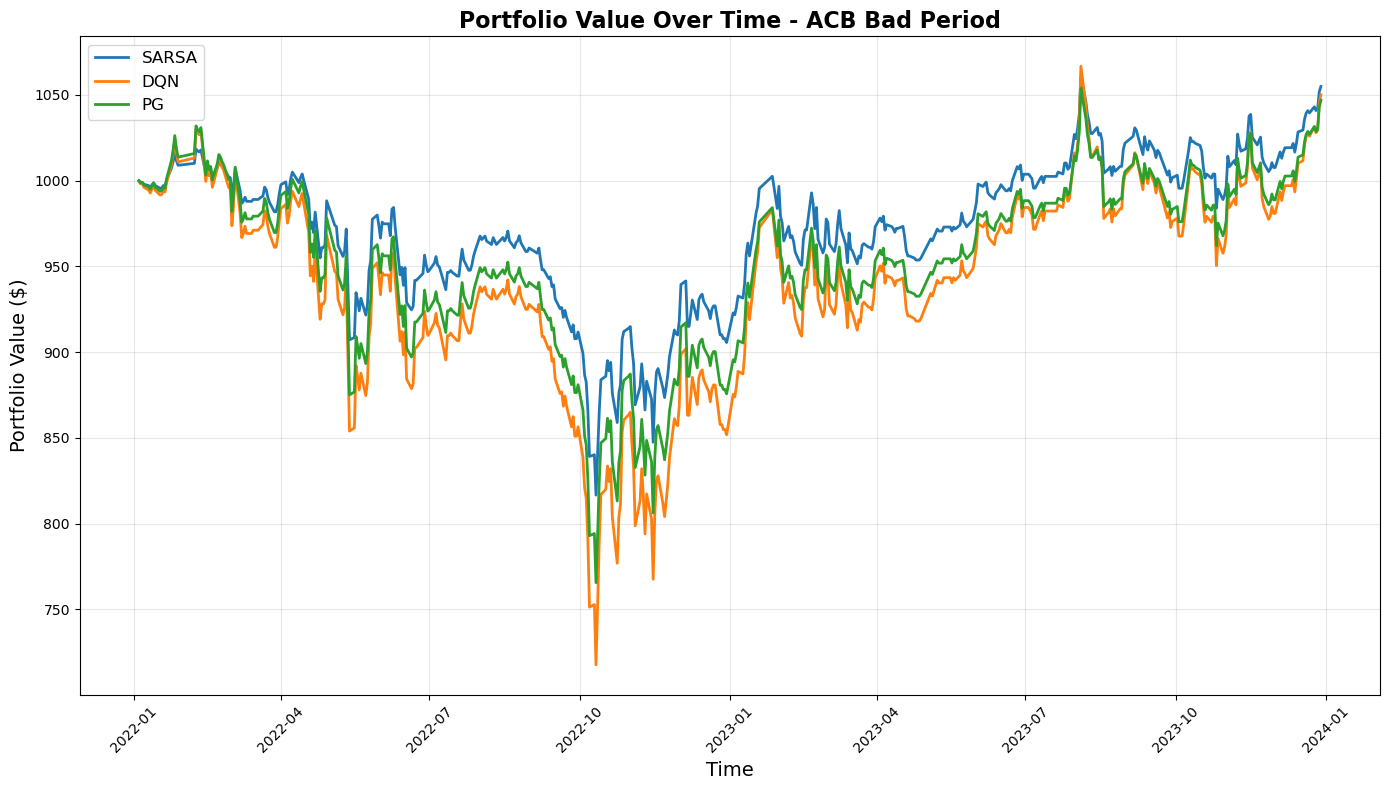

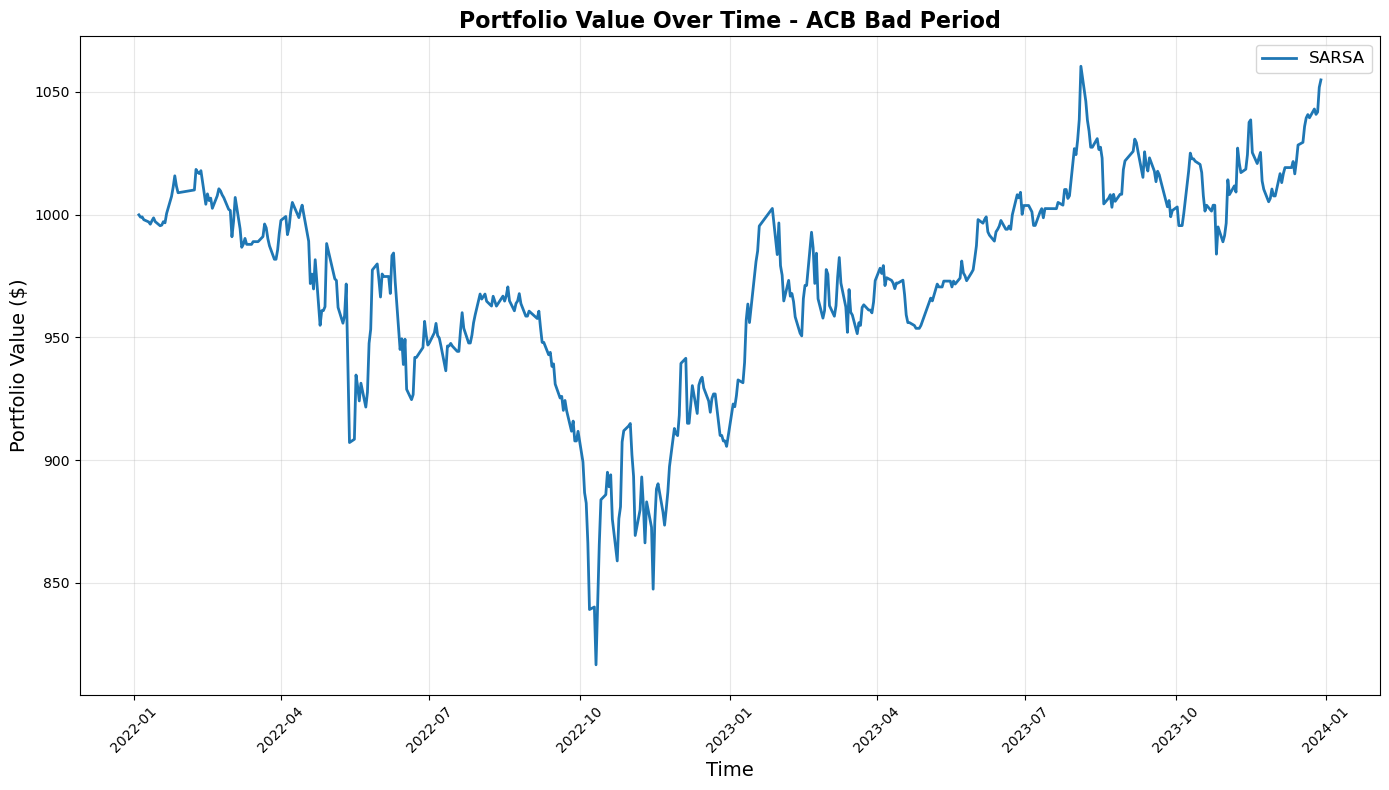

In [ ]:
# Vẽ đồ thị
portfolio_histories = {}
for agent_name in ['sarsa', 'dqn', 'pg']:
    if agent_name in results:
        portfolio_histories[agent_name] = results[agent_name]['portfolio_history']

plt.figure(figsize=(14, 8))
for agent, port in portfolio_histories.items():
    # Cắt portfolio_history để khớp với len(test['time'])
    plt.plot(test['time'], port[1:], label=agent.upper(), linewidth=2)

plt.title('Portfolio Value Over Time - SSI Bad Period', fontsize=16, fontweight='bold')
plt.xlabel('Time', fontsize=14)
plt.ylabel('Portfolio Value ($)', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
# Vẽ đồ thị
portfolio_histories = {}
for agent_name in ['sarsa']:
    if agent_name in results:
        portfolio_histories[agent_name] = results[agent_name]['portfolio_history']

plt.figure(figsize=(14, 8))
for agent, port in portfolio_histories.items():
    # Cắt portfolio_history để khớp với len(test['time'])
    plt.plot(test['time'], port[1:], label=agent.upper(), linewidth=2)

plt.title('Portfolio Value Over Time - SSI Bad Period', fontsize=16, fontweight='bold')
plt.xlabel('Time', fontsize=14)
plt.ylabel('Portfolio Value ($)', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
import os

models_dir = r'D:\nckh\SARSA_FinancialRL\models'

os.makedirs(models_dir, exist_ok=True)

# Save trained models for SSI bad period
if 'sarsa' in results:
    torch.save(results['sarsa']['trained_agent'].state_dict(), os.path.join(models_dir, 'sarsa_bad.pth'))
    print("Deep SARSA model saved.")

if 'dqn' in results:
    results['dqn']['trained_agent'].save(os.path.join(models_dir, 'dqn_bad.pth'))
    print("DQN model saved.")

if 'pg' in results:
    results['pg']['trained_agent'].save_model(os.path.join(models_dir, 'pg_bad.pth'))
    print("Policy Gradient model saved.")

print("All models for SSI bad period saved successfully!")

Deep SARSA model saved.
DQN model saved.
Policy Gradient model saved.
All models for FPT bad period saved successfully!


In [ ]:
from reportlab.lib.pagesizes import letter
from reportlab.pdfgen import canvas
from reportlab.lib import colors
from reportlab.platypus import SimpleDocTemplate, Table, TableStyle, Paragraph, Spacer, Image
from reportlab.lib.styles import getSampleStyleSheet
import os

# Đảm bảo thư mục tồn tại
results_dir = r'D:\nckh\SARSA_FinancialRL\application\results'
os.makedirs(results_dir, exist_ok=True)

# Tạo PDF
pdf_path = os.path.join(results_dir, 'SSI_bad_goc.pdf')
doc = SimpleDocTemplate(pdf_path, pagesize=letter)
elements = []
styles = getSampleStyleSheet()

# Title
elements.append(Paragraph("Training Results for SSI Bad Period", styles['Title']))
elements.append(Spacer(1, 12))

# Hyperparameters
elements.append(Paragraph("Hyperparameters:", styles['Heading2']))
hp_text = f"""
Episodes: {shared_config['episodes']}
Gamma: {shared_config['gamma']}
Alpha: {shared_config['alpha']}
Epsilon Start: {shared_config['epsilon_start']}
Epsilon Min: {shared_config['epsilon_min']}
Epsilon Decay: {shared_config['epsilon_decay']}
NN Epochs: {shared_config['nn_epochs']}
NN LR: {shared_config['nn_lr']}
Enabled Agents: {shared_config['enabled_agents']}
"""
elements.append(Paragraph(hp_text, styles['Normal']))
elements.append(Spacer(1, 12))

# Results Table
elements.append(Paragraph("Training Results:", styles['Heading2']))

# Tạo data cho table với các chỉ số mới
data = [['Agent', 'Avg Profit', 'ROI', 'Annual Return', 'Volatility', 'Sharpe Ratio', 'Max Drawdown']]
for agent in agents:
    if agent in results:
        res = results[agent]
        avg_profit = f"${res['final_profit']:.2f}"
        roi = f"{res['roi']:.2f}%"
        final_portfolio = 1000 + res['final_profit']
        annual_rate, total_rate = agent_annual_return(1000, final_portfolio, start_date, end_date)
        annual = f"{annual_rate:.2f}%"
        volatility = f"{res['volatility']:.2f}%"
        sharpe = f"{res['sharpe_ratio']:.4f}"
        drawdown = f"{res['max_drawdown']:.2f}%"
        data.append([res['agent'], avg_profit, roi, annual, volatility, sharpe, drawdown])

# Baseline
baseline_avg = f"${np.mean(profits):.2f}"
baseline_final_portfolio = 1000 + np.mean(profits)
baseline_annual_rate, baseline_total_rate = agent_annual_return(1000, baseline_final_portfolio, start_date, end_date)
data.append(['Random Baseline', baseline_avg, f"{((np.mean(profits)/1000)*100):.2f}%", f"{baseline_annual_rate:.2f}%", 'N/A', 'N/A', 'N/A'])

table = Table(data)
table.setStyle(TableStyle([
    ('BACKGROUND', (0,0), (-1,0), colors.grey),
    ('TEXTCOLOR', (0,0), (-1,0), colors.whitesmoke),
    ('ALIGN', (0,0), (-1,-1), 'CENTER'),
    ('FONTNAME', (0,0), (-1,0), 'Helvetica-Bold'),
    ('FONTSIZE', (0,0), (-1,-1), 8),
    ('BOTTOMPADDING', (0,0), (-1,0), 12),
    ('BACKGROUND', (0,1), (-1,-1), colors.beige),
    ('GRID', (0,0), (-1,-1), 1, colors.black)
]))
elements.append(table)
elements.append(Spacer(1, 12))

# Detailed Statistics Table
elements.append(Paragraph("Detailed Statistics:", styles['Heading2']))
detailed_data = [['Agent', 'Best Profit', 'Worst Profit', 'Peak Training', 'Total Return']]
for agent in agents:
    if agent in results:
        res = results[agent]
        best = f"${np.max(res['all_final_profits']):.2f}"
        worst = f"${np.min(res['all_final_profits']):.2f}"
        peak = f"${np.max(res['learning_curve']):.2f}" if len(res['learning_curve']) > 0 else 'N/A'
        final_portfolio = 1000 + res['final_profit']
        annual_rate, total_rate = agent_annual_return(1000, final_portfolio, start_date, end_date)
        total = f"{total_rate:.2f}%"
        detailed_data.append([res['agent'], best, worst, peak, total])

detailed_table = Table(detailed_data)
detailed_table.setStyle(TableStyle([
    ('BACKGROUND', (0,0), (-1,0), colors.grey),
    ('TEXTCOLOR', (0,0), (-1,0), colors.whitesmoke),
    ('ALIGN', (0,0), (-1,-1), 'CENTER'),
    ('FONTNAME', (0,0), (-1,0), 'Helvetica-Bold'),
    ('BOTTOMPADDING', (0,0), (-1,0), 12),
    ('BACKGROUND', (0,1), (-1,-1), colors.beige),
    ('GRID', (0,0), (-1,-1), 1, colors.black)
]))
elements.append(detailed_table)
elements.append(Spacer(1, 12))

# Biểu đồ Learning Curves
elements.append(Paragraph("Learning Curves:", styles['Heading2']))
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, (agent, title) in enumerate(zip(agents, titles)):
    if agent in results:
        res = results[agent]
        mean_curve = res['learning_curve']
        axes[i].plot(mean_curve, label='Mean Profit')
        axes[i].set_title(f'{title} Learning Curve')
        axes[i].set_xlabel('Episode')
        axes[i].set_ylabel('Profit ($)')
        axes[i].legend()
        axes[i].grid(alpha=0.3)
plt.tight_layout()
learning_curve_path = os.path.join(results_dir, 'learning_curves.png')
plt.savefig(learning_curve_path)
plt.close()
elements.append(Image(learning_curve_path, width=500, height=300))

# Biểu đồ Percentiles
elements.append(Paragraph("Profit Percentiles:", styles['Heading2']))
agent_names = titles
plt.figure(figsize=(12, 8))
color_list = ['blue', 'green', 'red']
for i, (agent, name) in enumerate(zip(agents, agent_names)):
    if agent in results:
        agent_profits = results[agent]['all_final_profits']
        sorted_profits = np.sort(agent_profits)
        percentile_values = np.percentile(sorted_profits, percentile_levels)
        plt.plot(percentile_levels, percentile_values, color=color_list[i], marker='o', linestyle='-', label=name, linewidth=2, markersize=4)
plt.title('Độ biến thiên hiệu suất qua mỗi vòng lặp - SSI', fontsize=16, fontweight='bold')
plt.xlabel('Percentile (%)', fontsize=14)
plt.ylabel('Profit ($)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.xticks(percentile_levels)
plt.tight_layout()
percentile_path = os.path.join(results_dir, 'percentiles.png')
plt.savefig(percentile_path)
plt.close()
elements.append(Image(percentile_path, width=500, height=400))

# Biểu đồ Portfolio Value Over Time
elements.append(Paragraph("Portfolio Value Over Time:", styles['Heading2']))
portfolio_histories = {}
for agent_name in ['sarsa', 'dqn', 'pg']:
    if agent_name in results:
        portfolio_histories[agent_name] = results[agent_name]['portfolio_history']

plt.figure(figsize=(14, 8))
for agent, port in portfolio_histories.items():
    plt.plot(test['time'], port[1:], label=agent.upper(), linewidth=2)
plt.title('Portfolio Value Over Time - SSI Bad Period', fontsize=16, fontweight='bold')
plt.xlabel('Time', fontsize=14)
plt.ylabel('Portfolio Value ($)', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
portfolio_path = os.path.join(results_dir, 'portfolio_value_SSI_bad.png')
plt.savefig(portfolio_path)
plt.close()
elements.append(Image(portfolio_path, width=500, height=400))

# Build PDF
doc.build(elements)
print(f"PDF saved to {pdf_path}")

PDF saved to D:\nckh\SARSA_FinancialRL\application\results\FPT_bad_goc.pdf


🧪 TEST: Agent quyết định BÁN khi chưa có cổ phiếu

📋 TRƯỚC KHI GỌI update_state():
   • Action agent chọn: -3 (bán 3 cổ)
   • Shares hiện có: 0
   • Balance hiện có: $1000.00

✅ SAU KHI update_state() ĐIỀU CHỈNH:
   • Shares sau: 0.0
   • Balance sau: $1000.00
   • Price mới: $105.00

🎯 KẾT LUẬN:
   ✅ HỆ THỐNG ĐÃ CHẶN invalid action!
   ✅ Shares và Balance KHÔNG ĐỔI
   ✅ Không có giao dịch nào xảy ra

